In [8]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


In [ ]:
# Importing the training set
train_path = 'Google_Stock_Price_Train.csv' if os.path.exists('Google_Stock_Price_Train.csv') else os.path.join('CH-1', 'Google_Stock_Price_Train.csv')
dataset_train = pd.read_csv(train_path)
training_set = dataset_train.iloc[:, 1:2].values


In [ ]:
# Feature Scaling
try:
    from sklearn.preprocessing import MinMaxScaler
except Exception:
    # Pure-Python/NumPy fallback if scikit-learn C-extensions are blocked by Windows Application Control
    class MinMaxScaler:
        def __init__(self, feature_range=(0, 1)):
            self.feature_range = feature_range
            self.data_min_ = None
            self.data_max_ = None

        def fit(self, X, y=None):
            X = np.asarray(X)
            self.data_min_ = X.min(axis=0) 
            self.data_max_ = X.max(axis=0)
            return self

        def transform(self, X):
            X = np.asarray(X)
            X_std = (X - self.data_min_) / (self.data_max_ - self.data_min_)
            return X_std * (self.feature_range[1] - self.feature_range[0]) + self.feature_range[0]

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

        def inverse_transform(self, X):
            X = np.asarray(X)
            return (X - self.feature_range[0]) / (self.feature_range[1] - self.feature_range[0]) * (self.data_max_ - self.data_min_) + self.data_min_

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)


In [11]:
# Create a data structure with 60 timesteps and 1 output
x_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    x_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshaping
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [12]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Input


In [13]:
# Initializing the RNN
regressor = Sequential()

# Adding the first LSTM layer and Dropout regularisation
regressor.add(Input(shape=(x_train.shape[1], 1)))
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a second LSTM layer and Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding a third LSTM layer and Dropout regularisation
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Adding the fourth LSTM layer and Dropout regularisation
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units=1))


In [14]:
# Compiling the RNN
regressor.compile(optimizer='adam', loss='mean_squared_error')

# Fitting the RNN to the training set
regressor.fit(x_train, y_train, epochs=100, batch_size=32)


Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0462
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0067
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0059
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0051
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0055
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0050
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0046
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0046
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0051
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0045
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0047
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0038
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0040
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0040
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - lo

In [16]:
# Part 3 -> Making the predictions and visualizing the results

# Getting the real stock price of 2017
test_path = 'Google_Stock_Price_Test.csv' if os.path.exists('Google_Stock_Price_Test.csv') else os.path.join('CH-1', 'Google_Stock_Price_Test.csv')
dataset_test = pd.read_csv(test_path)
real_stock_price = dataset_test.iloc[:, 1:2].values


In [17]:
# Getting the predicted stock price of 2017
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

x_test = []
for i in range(60, 60 + len(dataset_test)):
    x_test.append(inputs[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


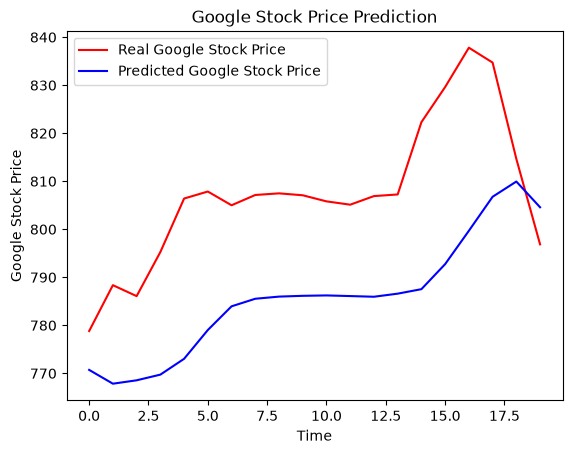

In [18]:
# Visualizing the results
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()
